In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv(
    r"C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\raw\Crop_recommendation.csv"
)

In [2]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,37,25,41,25.841,59.279,6.838,503.806,Kurakkan
1,41,29,30,28.051,57.852,6.610,390.045,Kurakkan
2,45,40,24,24.969,53.200,6.777,635.893,Kurakkan
3,41,17,36,27.440,55.111,6.907,560.032,Kurakkan
4,46,25,29,29.339,58.222,5.223,703.344,Kurakkan


In [3]:
df.shape

(1500, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            1500 non-null   int64  
 1   P            1500 non-null   int64  
 2   K            1500 non-null   int64  
 3   temperature  1500 non-null   float64
 4   humidity     1500 non-null   float64
 5   ph           1500 non-null   float64
 6   rainfall     1500 non-null   float64
 7   label        1500 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 93.9+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,1500.0,54.746667,24.552428,0.000000,36.00000,52.000000,71.000000,145.000000
P,1500.0,42.819333,15.610503,17.000000,32.00000,40.000000,50.000000,113.000000
K,1500.0,46.810000,32.460361,15.000000,26.00000,35.000000,49.000000,170.000000
temperature,1500.0,25.744035,3.513015,15.705000,23.29900,26.267000,28.419500,33.368000
humidity,1500.0,65.081096,10.676437,35.643000,57.41200,64.128500,72.348500,89.996156
ph,1500.0,6.336142,0.522236,5.076000,5.96200,6.352236,6.701443,7.753000
rainfall,1500.0,522.223109,369.227437,36.120429,111.62775,559.871000,748.810250,1717.781000


### Check for missing values

In [6]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nTotal missing cells:", missing.sum())

Missing values per column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total missing cells: 0


### Check for duplicates

In [7]:
dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {dupes}")

dupes_no_label = df.drop(columns='label').duplicated().sum()
print(f"Rows with identical feature values (label ignored): {dupes_no_label}")

Fully duplicated rows: 0
Rows with identical feature values (label ignored): 0


In [8]:
# Confirm dtypes are as expected and label is a clean string column
print(df.dtypes)
print("\nAny leading/trailing whitespace in labels?",
      any(df['label'] != df['label'].str.strip()))
df['label'] = df['label'].str.strip()

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Any leading/trailing whitespace in labels? False


No missing values and no duplicate rows were found, and the target labels are already
clean strings. This dataset requires no imputation.


### Target class balance

label
Kurakkan            100
Maize               100
Sorghum             100
Meneri              100
Green Gram          100
Cowpea              100
Gingelly            100
Ground Nuts         100
Manioc              100
Sweet Potatoes      100
Potatoes            100
Red Onion           100
Big Onion           100
Chillies (Green)    100
Mustard             100
Name: count, dtype: int64


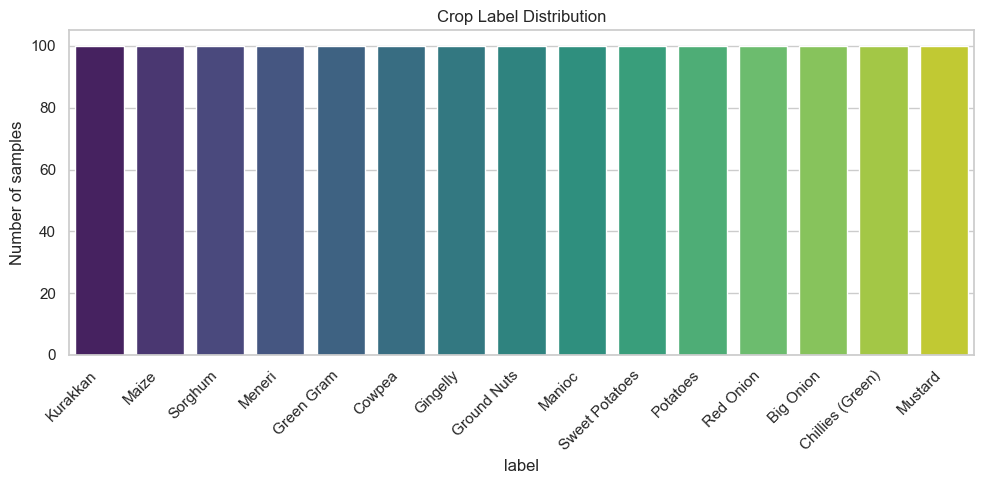

In [18]:
import os

# Create output folder if it does not exist
OUTPUT_DIR = r'C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\outputs\notebooks_task2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Count samples for each crop
label_counts = df['label'].value_counts()

print(label_counts)

# Plot crop distribution
plt.figure(figsize=(10, 5))

sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    hue=label_counts.index,
    palette='viridis',
    legend=False
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of samples')
plt.title('Crop Label Distribution')

plt.tight_layout()

# Save graph
plt.savefig(
    os.path.join(OUTPUT_DIR, '01_crop_label_distribution.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

The dataset is **perfectly balanced**: 15 crop classes, 100 samples each (1500 rows
total). This means:
- No resampling (SMOTE, class weighting, etc.) is needed for classification.


### Distribution of each numeric feature

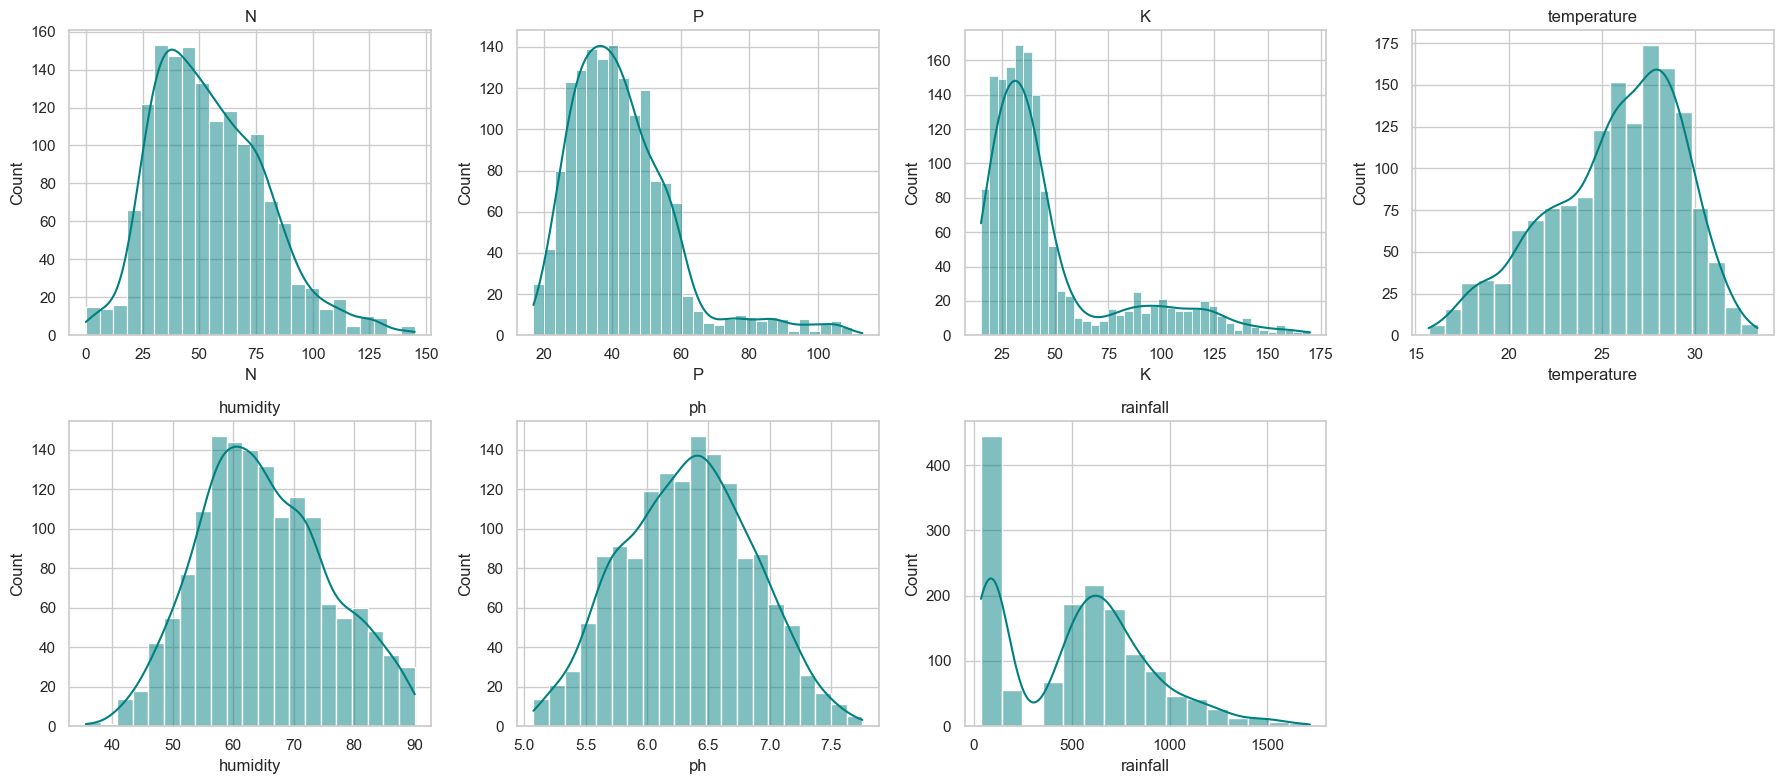

In [19]:
num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '02_numeric_feature_distributions.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### Outlier detection (IQR method, per feature)

In [20]:
def iqr_outlier_summary(data, cols):
    rows = []
    for col in cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append({'feature': col, 'lower_bound': round(lower, 2),
                     'upper_bound': round(upper, 2), 'n_outliers': n_out,
                     'pct_outliers': round(100 * n_out / len(data), 2)})
    return pd.DataFrame(rows)

outlier_summary = iqr_outlier_summary(df, num_cols)
outlier_summary

,feature,lower_bound,upper_bound,n_outliers,pct_outliers
0,N,-16.50,123.50,18,1.20
1,P,5.00,77.00,63,4.20
2,K,-8.50,83.50,238,15.87
3,temperature,15.62,36.10,0,0.00
4,humidity,35.01,94.75,0,0.00
5,ph,4.85,7.81,0,0.00
6,rainfall,-844.15,1704.58,1,0.07


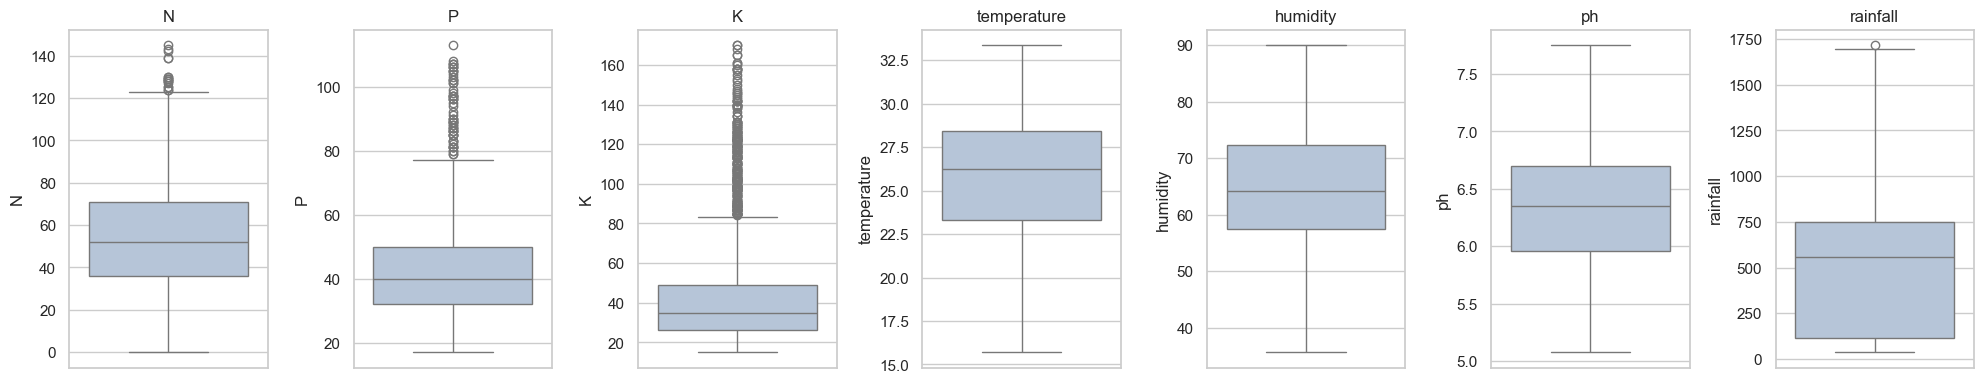

In [21]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightsteelblue')
    axes[i].set_title(col)
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '03_numeric_feature_boxplots.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

In [22]:

def per_class_outliers(data, cols, label_col='label'):
    out_counts = {c: 0 for c in cols}
    for _, g in data.groupby(label_col):
        for col in cols:
            q1, q3 = g[col].quantile([0.25, 0.75])
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            out_counts[col] += ((g[col] < lower) | (g[col] > upper)).sum()
    return pd.Series(out_counts).sort_values(ascending=False)

per_class_outliers(df, num_cols)

N              1
K              1
P              0
temperature    0
humidity       0
ph             0
rainfall       0
dtype: int64

### Feature correlations

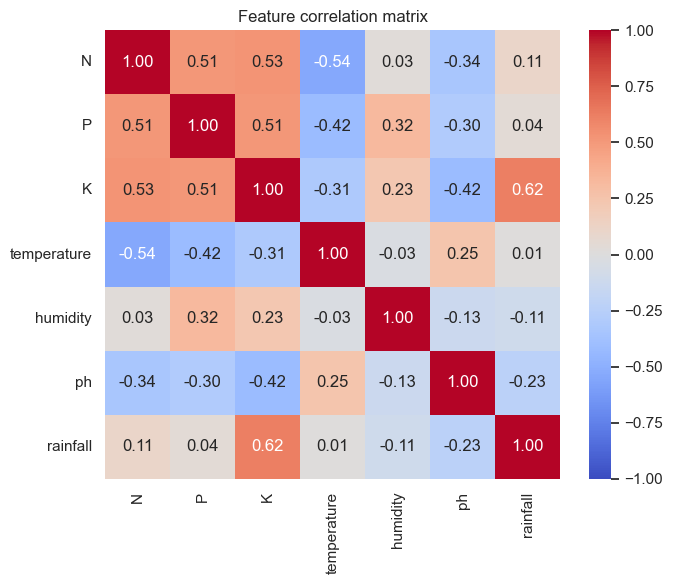

In [23]:
corr = df[num_cols].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature correlation matrix')
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '04_feature_correlation_matrix.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### Relationship between features and target (boxplots by crop)

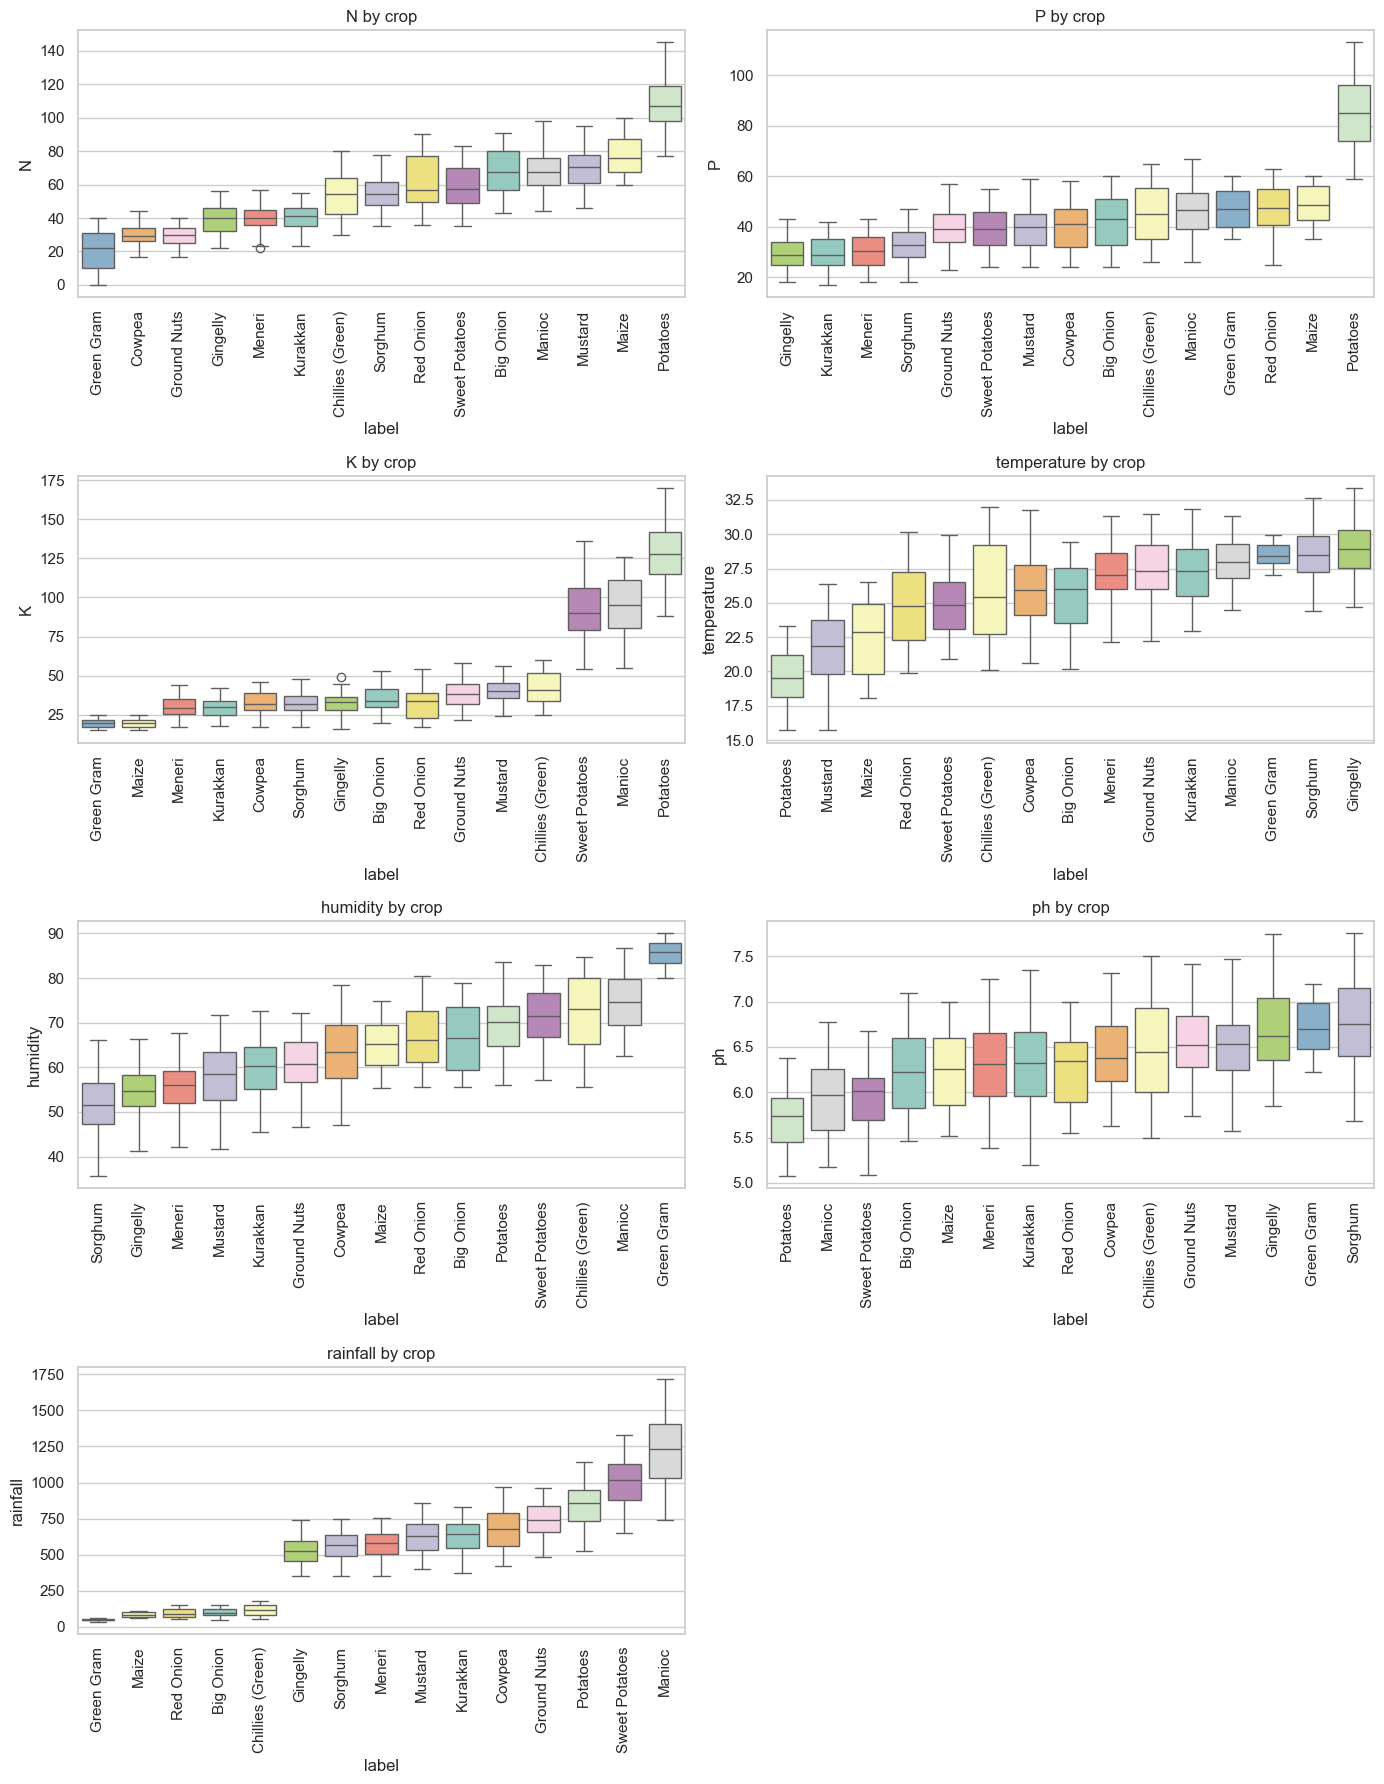

In [24]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    order = df.groupby('label')[col].median().sort_values().index
    sns.boxplot(data=df, x='label', y=col, order=order, ax=axes[i], hue='label',
                palette='Set3', legend=False)
    axes[i].set_title(f'{col} by crop')
    axes[i].tick_params(axis='x', rotation=90)
axes[-1].axis('off')
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '05_boxplots_by_crop.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### Encoding the target label

In [25]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
label_mapping

{'Big Onion': 0,
 'Chillies (Green)': 1,
 'Cowpea': 2,
 'Gingelly': 3,
 'Green Gram': 4,
 'Ground Nuts': 5,
 'Kurakkan': 6,
 'Maize': 7,
 'Manioc': 8,
 'Meneri': 9,
 'Mustard': 10,
 'Potatoes': 11,
 'Red Onion': 12,
 'Sorghum': 13,
 'Sweet Potatoes': 14}

### Train/test split (stratified)

In [26]:
X = df[num_cols]
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).sort_index())

Train shape: (1200, 7) Test shape: (300, 7)

Train class balance:
label_encoded
0     0.066667
1     0.066667
2     0.066667
3     0.066667
4     0.066667
5     0.066667
6     0.066667
7     0.066667
8     0.066667
9     0.066667
10    0.066667
11    0.066667
12    0.066667
13    0.066667
14    0.066667
Name: proportion, dtype: float64


We split **before** scaling and stratify on the label so every crop keeps its
80/20 split — with only 100 samples per class, an unstratified split could easily under- or
over-represent a class in the test set.


### Feature scaling

In [27]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=num_cols,
                               index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=num_cols,
                              index=X_test.index)

X_train_scaled.describe().T[['mean', 'std']]

,mean,std
N,-1.491400e-16,1.000417
P,6.513308e-17,1.000417
K,-5.773160e-17,1.000417
temperature,3.497203e-16,1.000417
humidity,2.664535e-17,1.000417
ph,8.334074e-16,1.000417
rainfall,-1.702342e-17,1.000417


### Save processed outputs

In [28]:
import os

OUTPUT_DIR = r'C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\processed\crop_recom'

# Create crop_recom folder if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save cleaned dataset
df.to_csv(
    os.path.join(OUTPUT_DIR, 'crop_recommendation_clean.csv'),
    index=False
)

# Save model-ready splits
X_train.to_csv(
    os.path.join(OUTPUT_DIR, 'crop_recom_X_train.csv'),
    index=False
)

X_test.to_csv(
    os.path.join(OUTPUT_DIR, 'crop_recom_X_test.csv'),
    index=False
)

X_train_scaled.to_csv(
    os.path.join(OUTPUT_DIR, 'crop_recom_X_train_scaled.csv'),
    index=False
)

X_test_scaled.to_csv(
    os.path.join(OUTPUT_DIR, 'crop_recom_X_test_scaled.csv'),
    index=False
)

y_train.to_csv(
    os.path.join(OUTPUT_DIR, 'crop_recom_y_train.csv'),
    index=False
)

y_test.to_csv(
    os.path.join(OUTPUT_DIR, 'crop_recom_y_test.csv'),
    index=False
)

# Save label mapping
pd.Series(label_mapping).to_csv(
    os.path.join(OUTPUT_DIR, 'crop_recommendation_label_mapping.csv'),
    header=['encoded_value']
)

print("Saved successfully to:")
print(OUTPUT_DIR)

Saved successfully to:
C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\processed\crop_recom


In [29]:
import os
import pandas as pd
import numpy as np

# Exact crop recommendation processed folder
CROP_RECOM_DIR = r'C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\processed\crop_recom'

# Load training and testing datasets
X_train = pd.read_csv(
    os.path.join(CROP_RECOM_DIR, 'crop_recom_X_train.csv')
)

X_test = pd.read_csv(
    os.path.join(CROP_RECOM_DIR, 'crop_recom_X_test.csv')
)

y_train = pd.read_csv(
    os.path.join(CROP_RECOM_DIR, 'crop_recom_y_train.csv')
)

y_test = pd.read_csv(
    os.path.join(CROP_RECOM_DIR, 'crop_recom_y_test.csv')
)

# Convert feature DataFrames to NumPy arrays
X_train = X_train.values
X_test = X_test.values

# Convert target columns to 1D NumPy arrays
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# Save everything into one compressed NPZ file
NPZ_PATH = os.path.join(
    CROP_RECOM_DIR,
    'crop_recommendation_data.npz'
)

np.savez_compressed(
    NPZ_PATH,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test
)

print("NPZ file created successfully!")
print("Saved to:", NPZ_PATH)

print("\nDataset shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

NPZ file created successfully!
Saved to: C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\processed\crop_recom\crop_recommendation_data.npz

Dataset shapes:
X_train: (1200, 7)
X_test: (300, 7)
y_train: (1200,)
y_test: (300,)


In [30]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Exact folders
RAW_FILE = r'C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\raw\Crop_recommendation.csv'

PROC_DIR = r'C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\processed\crop_recom'

MODEL_DIR = r'C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\models'

os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# Load crop recommendation dataset
crop_recom = pd.read_csv(RAW_FILE)

# Copy dataset
bench = crop_recom.copy()

# Encode target labels
bench_label_encoder = LabelEncoder()

bench['label_enc'] = bench_label_encoder.fit_transform(
    bench['label']
)

# Save label encoder
joblib.dump(
    bench_label_encoder,
    os.path.join(MODEL_DIR, 'label_encoder_benchmark.pkl')
)

# Features
bench_features = [
    'N',
    'P',
    'K',
    'temperature',
    'humidity',
    'ph',
    'rainfall'
]

Xb = bench[bench_features].values
yb = bench['label_enc'].values

# Train-test split
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb,
    yb,
    test_size=0.2,
    random_state=42,
    stratify=yb
)

# Scale features
bench_scaler = StandardScaler()

Xb_train_scaled = bench_scaler.fit_transform(Xb_train)
Xb_test_scaled = bench_scaler.transform(Xb_test)

# Save scaler
joblib.dump(
    bench_scaler,
    os.path.join(MODEL_DIR, 'scaler_benchmark.pkl')
)

# Save train/test split
np.savez_compressed(
    os.path.join(PROC_DIR, 'benchmark_train_test_split.npz'),
    X_train=Xb_train_scaled,
    X_test=Xb_test_scaled,
    y_train=yb_train,
    y_test=yb_test
)

# Save processed dataset
bench.to_csv(
    os.path.join(PROC_DIR, 'benchmark_processed.csv'),
    index=False
)

print(
    'Benchmark dataset processed:',
    Xb_train_scaled.shape,
    Xb_test_scaled.shape
)

Benchmark dataset processed: (1200, 7) (300, 7)
